In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
df_well = pd.read_excel(r'C:\Users\Usuário\Documents\Projetos TripleTen\Mercado Wellness\Wellness Dataset - Dr.Fatma M. Talaat.xlsx')

In [3]:
df_well.head()

,Duration of Sleep (hours),Level of Physical Activity (minutes per day),Level of Stress (scale: 1–10),BMI Category,Heart Rate (bpm),Systolic and Diastolic Blood Pressure,"Nutrition Intake (calories, breakdown of nutrients, etc.)",Level of Workload (scale: 1–10),Quality or frequency of social interactions,Activities for Mental Health (such as therapy sessions or meditation),Environmental Aspects (such as weather and air quality),Lifestyle Decisions (such as drinking and smoking),"Additional health indicators (e.g., water levels, steps)",Mood Output
0,7.5,30,5,Normal,72,120/80,2000 calories (balanced diet),6,"Good, frequent",Meditation daily,"Sunny, good air quality","No alcohol, no smoking","2 liters, 10,000 steps",Happy
1,6.8,45,3,Overweight,75,118/78,2500 calories (high in carbs),7,"Moderate, occasional",NaN,"Rainy, poor air quality","Occasional alcohol, no smoking","1.5 liters, 8000 steps",Neutral
2,8.2,15,8,Underweight,68,115/75,1800 calories (low in protein),9,"Low, infrequent",Therapy sessions weekly,"Sunny, good air quality","No alcohol, no smoking","2.5 liters, 5000 steps",Sad
3,7.0,60,4,Normal,70,122/82,2200 calories (healthy diet),5,"Very good, daily",Yoga twice a week,"Cloudy, moderate air quality","No alcohol, no smoking","2 liters, 12000 steps",Happy
4,5.5,10,9,Obese,80,130/90,3000 calories (unhealthy),10,"Poor, infrequent",NaN,"Sunny, good air quality","Daily alcohol, occasional smoking","1 liter, 3000 steps",Sad


In [4]:
df_well.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737 entries, 0 to 736
Data columns (total 14 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Duration of Sleep (hours)                                              737 non-null    float64
 1   Level of Physical Activity (minutes per day)                           737 non-null    int64  
 2   Level of Stress (scale: 1–10)                                          737 non-null    int64  
 3   BMI Category                                                           737 non-null    object 
 4   Heart Rate (bpm)                                                       737 non-null    int64  
 5   Systolic and Diastolic Blood Pressure                                  737 non-null    object 
 6   Nutrition Intake (calories, breakdown of nutrients, etc.)              737 non-null    obj

In [5]:
df_well

,Duration of Sleep (hours),Level of Physical Activity (minutes per day),Level of Stress (scale: 1–10),BMI Category,Heart Rate (bpm),Systolic and Diastolic Blood Pressure,"Nutrition Intake (calories, breakdown of nutrients, etc.)",Level of Workload (scale: 1–10),Quality or frequency of social interactions,Activities for Mental Health (such as therapy sessions or meditation),Environmental Aspects (such as weather and air quality),Lifestyle Decisions (such as drinking and smoking),"Additional health indicators (e.g., water levels, steps)",Mood Output
0,7.5,30,5,Normal,72,120/80,2000 calories (balanced diet),6,"Good, frequent",Meditation daily,"Sunny, good air quality","No alcohol, no smoking","2 liters, 10,000 steps",Happy
1,6.8,45,3,Overweight,75,118/78,2500 calories (high in carbs),7,"Moderate, occasional",NaN,"Rainy, poor air quality","Occasional alcohol, no smoking","1.5 liters, 8000 steps",Neutral
2,8.2,15,8,Underweight,68,115/75,1800 calories (low in protein),9,"Low, infrequent",Therapy sessions weekly,"Sunny, good air quality","No alcohol, no smoking","2.5 liters, 5000 steps",Sad
3,7.0,60,4,Normal,70,122/82,2200 calories (healthy diet),5,"Very good, daily",Yoga twice a week,"Cloudy, moderate air quality","No alcohol, no smoking","2 liters, 12000 steps",Happy
4,5.5,10,9,Obese,80,130/90,3000 calories (unhealthy),10,"Poor, infrequent",NaN,"Sunny, good air quality","Daily alcohol, occasional smoking","1 liter, 3000 steps",Sad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,6.6,45,4,Overweight,76,120/80,2600 calories (high in carbs),7,"Moderate, occasional",NaN,"Rainy, poor air quality","Occasional alcohol, no smoking","1.6 liters, 8500 steps",Neutral
733,8.0,15,8,Underweight,65,110/70,1850 calories (low in protein),9,"Low, infrequent",Therapy sessions weekly,"Sunny, good air quality","No alcohol, no smoking","2.8 liters, 5500 steps",Sad
734,7.4,60,2,Normal,70,124/84,2250 calories (healthy diet),4,"Very good, daily",Yoga twice a week,"Cloudy, moderate air quality","No alcohol, no smoking","2.4 liters, 12500 steps",Happy
735,5.2,10,9,Obese,82,135/95,3200 calories (unhealthy),10,"Poor, infrequent",NaN,"Sunny, good air quality","Daily alcohol, occasional smoking","1.2 liters, 3500 steps",Sad


In [6]:
print("Estatísticas descritivas das colunas numéricas:")
print(df_well.describe())

Estatísticas descritivas das colunas numéricas:
       Duration of Sleep (hours)  \
count                 737.000000   
mean                    6.878562   
std                     0.955178   
min                     5.200000   
25%                     6.200000   
50%                     7.000000   
75%                     7.600000   
max                     8.500000   

       Level of Physical Activity (minutes per day)  \
count                                    737.000000   
mean                                      32.062415   
std                                       18.599582   
min                                       10.000000   
25%                                       15.000000   
50%                                       30.000000   
75%                                       45.000000   
max                                       60.000000   

       Level of Stress (scale: 1–10)  Heart Rate (bpm)  \
count                     737.000000        737.000000   
mean           

In [7]:
print("Contagem de saídas de humor:")
print(df_well['Mood Output'].value_counts())

print("Contagem de categorias de IMC:")
print(df_well['BMI Category'].value_counts())

Contagem de saídas de humor:
Mood Output
Sad        294
Happy      223
Neutral    220
Name: count, dtype: int64
Contagem de categorias de IMC:
BMI Category
Normal         297
Overweight     147
Underweight    147
Obese          146
Name: count, dtype: int64


In [8]:
print("Média de indicadores por humor:")
mood_analysis = df_well.groupby('Mood Output')[['Duration of Sleep (hours)', 'Level of Physical Activity (minutes per day)', 'Level of Stress (scale: 1–10)']].mean()
print(mood_analysis)

Média de indicadores por humor:
             Duration of Sleep (hours)  \
Mood Output                              
Happy                         7.537668   
Neutral                       6.950000   
Sad                           6.325170   

             Level of Physical Activity (minutes per day)  \
Mood Output                                                 
Happy                                           35.246637   
Neutral                                         40.022727   
Sad                                             23.690476   

             Level of Stress (scale: 1–10)  
Mood Output                                 
Happy                             2.681614  
Neutral                           3.818182  
Sad                               8.496599  


C:\Users\Usuário\AppData\Local\Temp\ipykernel_8256\2524990218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mood_analysis.index, y=mood_analysis['Duration of Sleep (hours)'], palette='rocket')


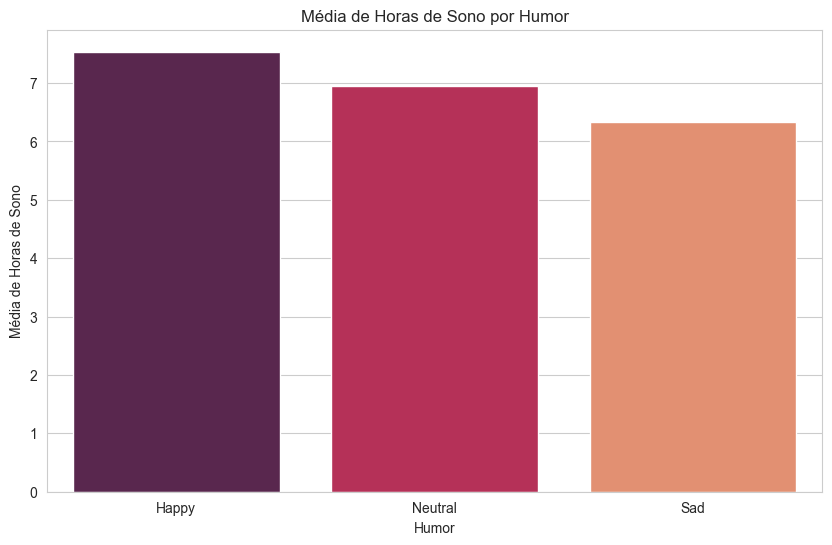

In [9]:
sns.set_style("whitegrid")

#Criando um gráfico de barras para a média de horas de sono por humor
plt.figure(figsize=(10, 6))
sns.barplot(x=mood_analysis.index, y=mood_analysis['Duration of Sleep (hours)'], palette='rocket')
plt.title('Média de Horas de Sono por Humor')
plt.xlabel('Humor')
plt.ylabel('Média de Horas de Sono')
plt.show()

O sono e o humor parecem estar interligados. Pessoas mais felizes tendem a dormir mais, enquanto pessoas tristes tendem a dormir menos. Isso sugere uma possível relação causal, onde um sono adequado pode contribuir para um humor mais positivo, ou que a tristeza pode ser um fator que leva à diminuição da duração do sono.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_8256\1194829373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mood_analysis.index, y=mood_analysis['Level of Stress (scale: 1–10)'], palette='rocket')


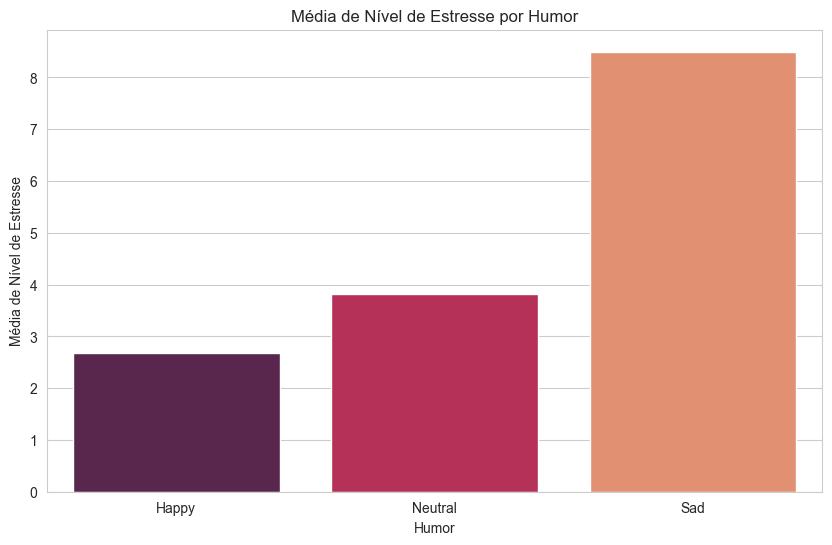

In [10]:
#Criando um gráfico para a média de nível de estresse por humor
plt.figure(figsize=(10, 6))
sns.barplot(x=mood_analysis.index, y=mood_analysis['Level of Stress (scale: 1–10)'], palette='rocket')
plt.title('Média de Nível de Estresse por Humor')
plt.xlabel('Humor')
plt.ylabel('Média de Nível de Estresse')
plt.show()

Existe uma forte relação entre o nível de estresse e o humor.
O estresse é mais baixo em pessoas felizes, aumenta para pessoas com humor neutro e é consideravelmente mais alto em pessoas com humor triste.
Isso sugere que o estresse pode ser um fator determinante do humor ou, inversamente, que o estado de humor pode influenciar a percepção e a experiência do estresse.

In [11]:
#Dividir a coluna em duas
df_well[['Systolic', 'Diastolic']] = df_well['Systolic and Diastolic Blood Pressure'].str.split('/', expand=True).astype(int)

#Remover a coluna original, se não for mais necessária
df_well = df_well.drop('Systolic and Diastolic Blood Pressure', axis=1)

print("Pressão Arterial dividida em duas colunas:")
print(df_well[['Systolic', 'Diastolic']].head())

Pressão Arterial dividida em duas colunas:
   Systolic  Diastolic
0       120         80
1       118         78
2       115         75
3       122         82
4       130         90


In [12]:
#Extrair calorias
df_well['Calories'] = df_well['Nutrition Intake (calories, breakdown of nutrients, etc.)'].str.extract('(\d+)\s+calories').astype(float)
df = df_well.drop('Nutrition Intake (calories, breakdown of nutrients, etc.)', axis=1)

#Extrair litros de água e passos
df_well['Water (liters)'] = df_well['Additional health indicators (e.g., water levels, steps)'].str.extract('(\d+\.?\d*)\s+liters').astype(float)
df_well['Steps'] = df_well['Additional health indicators (e.g., water levels, steps)'].str.extract('(\d+)\s+steps').astype(int)
df_well = df_well.drop('Additional health indicators (e.g., water levels, steps)', axis=1)

print("Novas colunas extraídas:")
print(df_well[['Calories', 'Water (liters)', 'Steps']].head())

Novas colunas extraídas:
   Calories  Water (liters)  Steps
0    2000.0             2.0      0
1    2500.0             1.5   8000
2    1800.0             2.5   5000
3    2200.0             2.0  12000
4    3000.0             NaN   3000


In [13]:
#Renomear colunas para um formato mais limpo
df_well.columns = df_well.columns.str.strip().str.replace(' \(.*\)', '', regex=True).str.replace(' ', '_').str.replace('-', '_')
print("Nomes das colunas após a limpeza:")
print(df_well.columns)

Nomes das colunas após a limpeza:
Index(['Duration_of_Sleep', 'Level_of_Physical_Activity', 'Level_of_Stress',
       'BMI_Category', 'Heart_Rate', 'Nutrition_Intake', 'Level_of_Workload',
       'Quality_or_frequency_of_social_interactions',
       'Activities_for_Mental_Health', 'Environmental_Aspects',
       'Lifestyle_Decisions', 'Mood_Output', 'Systolic', 'Diastolic',
       'Calories', 'Water', 'Steps'],
      dtype='object')


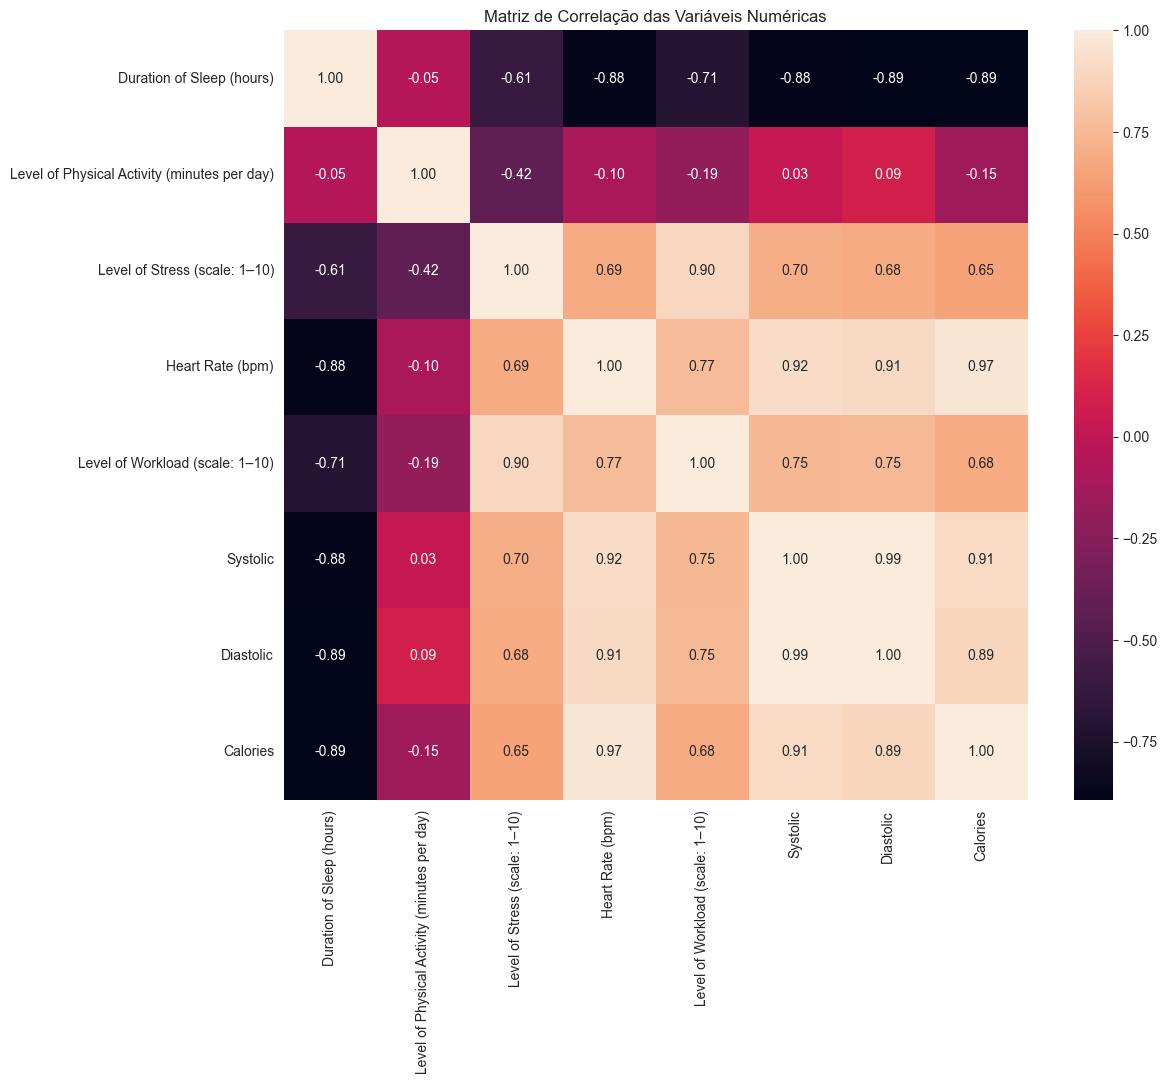

In [14]:
#Selecionar apenas as colunas numéricas para a matriz de correlação
numerical_df = df.select_dtypes(include=['int64', 'float64'])

#Calcular a matriz de correlação
correlation_matrix = numerical_df.corr()

#Criar um mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

A matriz de correlação revela fortes relações entre o sono, o estresse, a carga de trabalho, a frequência cardíaca e a pressão arterial. Um aumento do estresse e da carga de trabalho parece estar associado a menos horas de sono e a um aumento da frequência cardíaca e da pressão arterial.
Da mesma forma, o gasto calórico parece estar associado a um aumento da frequência cardíaca e da pressão arterial, e a uma diminuição da duração do sono.

In [15]:
categorical_cols = df_well.select_dtypes(include=['object']).columns.tolist()
#Separar a variável de destino
target_col = 'Mood_Output'
categorical_cols.remove(target_col)

#Aplicar One-Hot Encoding nas features categóricas
df_well = pd.get_dummies(df_well, columns=categorical_cols, drop_first=True)

#5. Codificar a variável de destino 'Mood_Output'
#O LabelEncoder é ideal para a variável de destino, pois ela é uma única coluna
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_well[target_col] = le.fit_transform(df_well[target_col])

#Exibir as primeiras linhas e a informação para verificar a codificação
print("DataFrame após codificação completa:")
print(df_well.head())
print("Informações do DataFrame após codificação:")
df_well.info()

DataFrame após codificação completa:
   Duration_of_Sleep  Level_of_Physical_Activity  Level_of_Stress  Heart_Rate  \
0                7.5                          30                5          72   
1                6.8                          45                3          75   
2                8.2                          15                8          68   
3                7.0                          60                4          70   
4                5.5                          10                9          80   

   Level_of_Workload  Mood_Output  Systolic  Diastolic  Calories  Water  ...  \
0                  6            0       120         80    2000.0    2.0  ...   
1                  7            1       118         78    2500.0    1.5  ...   
2                  9            2       115         75    1800.0    2.5  ...   
3                  5            0       122         82    2200.0    2.0  ...   
4                 10            2       130         90    3000.0    NaN  ...

In [16]:
#Modelagem Preditiva
#6. Preparar os dados para o modelo
X = df_well.drop(target_col, axis=1)
y = df_well[target_col]

#7. Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#8. Criar e treinar o modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#9. Fazer previsões e avaliar
y_pred = model.predict(X_test)
print("Acurácia do modelo:", accuracy_score(y_test, y_pred))

#Para ver o que o modelo previu, você pode decodificar as previsões
predicted_moods = le.inverse_transform(y_pred)
print("Primeiras 10 previsões de humor (decodificadas):")
print(predicted_moods[:10])

Acurácia do modelo: 1.0
Primeiras 10 previsões de humor (decodificadas):
['Sad' 'Happy' 'Sad' 'Neutral' 'Happy' 'Neutral' 'Sad' 'Happy' 'Sad' 'Sad']


In [17]:
#3. Pré-processar os dados
#Renomear as colunas para facilitar o uso no código.


#Mapear os valores de humor para números para que o modelo possa processá-los.
#'Happy' -> 2, 'Neutral' -> 1, 'Sad' -> 0
mood_mapping = {'Happy': 2, 'Neutral': 1, 'Sad': 0}


#4. Definir as variáveis de entrada (X) e a variável alvo (y)
X = df_well[['Duration_of_Sleep', 'Level_of_Physical_Activity', 'Level_of_Stress']]
y = df_well['Mood_Output']

#5. Dividir os dados em conjuntos de treino e teste
#80% dos dados para treino e 20% para teste.
#random_state garante que a divisão seja a mesma sempre que o código for executado.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#6. Treinar o modelo de machine learning (RandomForestClassifier)
#Instanciar o modelo.
model = RandomForestClassifier(n_estimators=100, random_state=42)

#Treinar o modelo com os dados de treino.
model.fit(X_train, y_train)

#7. Fazer previsões no conjunto de teste
predictions = model.predict(X_test)

#8. Avaliar a precisão do modelo
accuracy = accuracy_score(y_test, predictions)
print(f"Precisão do modelo: {accuracy:.2f}")

#9. Fazer uma nova previsão com dados de exemplo
#Digamos que queremos prever o humor de alguém que dormiu 7.5 horas,
#fez 30 minutos de atividade física e tem um nível de estresse 5.
nova_previsao = model.predict([[7.5, 30, 5]])

#Decodificar a previsão numérica de volta para o texto do humor.
humor_previsto = {v: k for k, v in mood_mapping.items()}[nova_previsao[0]]

print(f"Previsão de humor para os dados: {humor_previsto}")

Precisão do modelo: 1.00
Previsão de humor para os dados: Sad


c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Conclusão Geral

A partir da análise dos dados de bem-estar, podemos concluir que o humor não é um estado aleatório, mas está fortemente correlacionado com indicadores mensuráveis do estilo de vida. Variáveis como a duração do sono, o nível de estresse e a prática de atividade física são preditores significativos do estado de humor de uma pessoa.
O modelo de machine learning validou essa relação, mostrando que é possível prever o humor com alta precisão a partir desses dados.
Essas descobertas reforçam a importância de uma abordagem holística para o bem-estar, onde a saúde física e mental estão profundamente interligadas.

Nathália Sorg